In [118]:
import os
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import Normalize
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import PyComplexHeatmap as pch
import numpy as np
class MidpointNormalize(Normalize):
    """
    Normalize the colorbar so that 0 is at the center (white).
    Works for any matplotlib version.
    """
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        # Avoid modifying original data
        x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))



In [119]:
df_DAR = pd.read_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MAST1C_dar_annotated.csv')

In [120]:
df_DAR

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Subclass,Sex,Region Subclass,Ensemble,Gene,log2FC,Direction,Neurotransmitter,Gene_name,FDR
0,chr10:100456562-100457063,1.555484e-02,-0.003031,0.002325,-0.008388,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,0.037345,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000036676.14,chr10:100456562-100457063,-0.003031,Down,Glut,chr10:100456562-100457063,0.037345
1,chr10:100487209-100487710,9.113524e-06,0.037181,0.056570,0.017792,0.295725,HPF_CA3_Glut,HPF,HPF_CA3_Glut,0.000374,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000019971.10,chr10:100487209-100487710,0.037181,Up,Glut,chr10:100487209-100487710,0.000374
2,chr10:100487209-100487710,9.113524e-06,0.037181,0.056570,0.017792,0.295725,HPF_CA3_Glut,HPF,HPF_CA3_Glut,0.000374,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000019971.10,chr10:100487209-100487710,0.037181,Up,Glut,chr10:100487209-100487710,0.000374
3,chr10:100588995-100589496,6.286321e-06,0.009609,0.024807,-0.005589,0.203985,HPF_CA3_Glut,HPF,HPF_CA3_Glut,0.000295,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000046567.10,chr10:100588995-100589496,0.009609,Up,Glut,chr10:100588995-100589496,0.000295
4,chr10:100617158-100617659,9.015117e-05,-0.005086,0.008058,-0.018231,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,0.001442,...,HPF_CA3_Glut,M,HPF_CA3_Glut,ENSMUSG00000056912.12,chr10:100617158-100617659,-0.005086,Down,Glut,chr10:100617158-100617659,0.001442
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490882,chrX:170674831-170675332,3.435317e-04,-0.016281,-0.008830,-0.023732,1.000000,AMY_Zbtb7c_Vwa5b1_Glut,AMY,AMY_Zbtb7c_Vwa5b1_Glut,0.049712,...,AMY_Zbtb7c_Vwa5b1_Glut,M,AMY_Zbtb7c_Vwa5b1_Glut,ENSMUSG00000093806.1,chrX:170674831-170675332,-0.016281,Down,Glut,chrX:170674831-170675332,0.049712
490883,chrX:36807905-36808406,4.100461e-05,0.016503,0.035499,-0.002493,0.961271,AMY_Zbtb7c_Vwa5b1_Glut,AMY,AMY_Zbtb7c_Vwa5b1_Glut,0.010801,...,AMY_Zbtb7c_Vwa5b1_Glut,M,AMY_Zbtb7c_Vwa5b1_Glut,ENSMUSG00000084990.1,chrX:36807905-36808406,0.016503,Up,Glut,chrX:36807905-36808406,0.010801
490884,chrX:98890710-98891211,1.107551e-04,0.018598,0.033203,0.003993,1.000000,AMY_Zbtb7c_Vwa5b1_Glut,AMY,AMY_Zbtb7c_Vwa5b1_Glut,0.022192,...,AMY_Zbtb7c_Vwa5b1_Glut,M,AMY_Zbtb7c_Vwa5b1_Glut,ENSMUSG00000031214.13,chrX:98890710-98891211,0.018598,Up,Glut,chrX:98890710-98891211,0.022192
490885,chrY:90761439-90761940,4.304958e-05,0.016817,0.029516,0.004118,1.000000,AMY_Zbtb7c_Vwa5b1_Glut,AMY,AMY_Zbtb7c_Vwa5b1_Glut,0.011213,...,AMY_Zbtb7c_Vwa5b1_Glut,M,AMY_Zbtb7c_Vwa5b1_Glut,ENSMUSG00000095134.2,chrY:90761439-90761940,0.016817,Up,Glut,chrY:90761439-90761940,0.011213


In [121]:
df_ion = pd.read_excel('/data2st2/junyi/output/all_iron_channel/gene_list_all_iron_channel.xlsx')

In [132]:
df_ion

,Gene,Category,中文类别,中文名称 (Chinese name)
0,Cacna1c,Calcium ion,钙离子通道,电压门控钙离子通道-L型（Cav1.2）
1,Cacna1d,Calcium ion,钙离子通道,电压门控钙离子通道-L型（Cav1.3）
2,Cacna1f,Calcium ion,钙离子通道,电压门控钙离子通道-L型（Cav1.4）
3,Cacna1b,Calcium ion,钙离子通道,电压门控钙离子通道-N型（Cav2.2）
4,Cacna1a,Calcium ion,钙离子通道,电压门控钙离子通道-P/Q型（Cav2.1）
...,...,...,...,...
252,Asic1,Others,Others,质子门控阳离子通道-ASIC1
253,Asic2,Others,Others,质子门控阳离子通道-ASIC2
254,Asic3,Others,Others,质子门控阳离子通道-ASIC3
255,Asic4,Others,Others,质子门控阳离子通道-ASIC4


In [123]:
df_DAR_ion=df_DAR.merge(df_ion.loc[:, ['Gene','Category']], left_on='gene_name', right_on='Gene', how='inner')

In [124]:
df_DAR.Neurotransmitter.value_counts()

Glut    269716
NN      148876
GABA     72295
Name: Neurotransmitter, dtype: int64

In [125]:


# 你给的 Region 颜色
region_colors = {
    "HPF": "#E13127",
    "AMY": "#6DA1D5",
    # "TH":  "#863220",
    # "STR": "#8A60AA",
    # "HY":  "#D88A91",
    "PFC": "#F57E20",
    # "MB":  "#E0B362",
    # "iCTX": "#82C341",
}

# 自己定义一个神经递质颜色（示例，可按你实际情况改）
nt_colors = {
    "Glut": "#FFC000",
    "GABA": "#00B050",
    # "Dopa": "#ff7f0e",
    # "Hist": "#aa40fc",
    # "Chol": "#1f77b4",
    # "Sero": "#e377c2",
    "NN":   "#8c564b",
}

# 行 Category 颜色（示例，可按自己分类改）
# category_colors = {
#     "Module1": "#1f77b4",
#     "Module2": "#ff7f0e",
#     "Module3": "#2ca02c",
# }


def draw_complex_heatmap(df, value_col="nlogp"):
    """
    df: 包含 Gene_y, Region subclass, Region, Neurotransmitter, Category, value_col
    value_col: 用来画热图的数值列名，比如 'nlogp'、'logFC'、表达量等
    """

    # 1. 生成矩阵：行 = Gene_y，列 = Region subclass
    mat = (
        df.pivot_table(
            index="Gene_y",
            columns="Region Subclass",
            values=value_col,
            aggfunc="mean"   # 有重复时取平均，你也可以改成 'max'
        )
    )
    #mat.clip(lower=-10, upper=10, inplace=True)  # 可选：裁剪极端值，防止颜色失真

    # 2. 准备列注释：Region + Neurotransmitter
    col_meta = (
        df[["Region Subclass", "Region", "Neurotransmitter"]]
        .drop_duplicates(subset="Region Subclass")
        .set_index("Region Subclass")
    )
    col_meta = col_meta.loc[mat.columns]

    # 让列按 Region 排序（同一脑区聚在一起）
    col_meta = col_meta.sort_values("Region")
    mat = mat[col_meta.index]

    region = col_meta["Region"]
    nt = col_meta["Neurotransmitter"]

    # 3. 准备行注释：Category
    row_meta = (
        df[["Gene_y", "Category"]]
        .drop_duplicates(subset="Gene_y")
        .set_index("Gene_y")
    )
    row_meta = row_meta.loc[mat.index]
    category = row_meta["Category"]

    # 4. 列注释（顶端）：Region + Neurotransmitter
    col_ha = pch.HeatmapAnnotation(
        Region=pch.anno_simple(region, colors=region_colors, add_text=True),
        Neurotransmitter=pch.anno_simple(nt, colors=nt_colors, add_text=False),
        axis=1
    )

    # 5. 行注释（左侧）：Category
    row_ha = pch.HeatmapAnnotation(
        Category=pch.anno_simple(category, add_text=False),
        axis=0
    )

    # 6. 画图
    #   这里用一个对称的渐变色图：蓝 - 白 - 橙，你可以自由改 cmap
    cmap = LinearSegmentedColormap.from_list(
        "blue_white_orange",
        ["#3B4CC0", "white", "#EE6A24"]
    )

    plt.figure(figsize=(10, 14))
    norm = MidpointNormalize(
        vmin=np.nanmin(mat.values),
        vmax=np.nanmax(mat.values),
        midpoint=0     # ← center at zero
    )

    cm = pch.ClusterMapPlotter(
        data=mat,
        top_annotation=col_ha,      # 列注释：Region + NT
        left_annotation=row_ha,     # 行注释：Category
        col_split=region,           # 列按 Region 分块
        row_split=category,         # 行按 Category 分块
        row_cluster=False,
        row_dendrogram=False,
        col_cluster=True,
        col_dendrogram=False,
        show_rownames=True,
        show_colnames=True,
        cmap=cmap,
        norm=norm,              # ← ★★ center at ZERO ★★

        label=value_col,
        rasterized=True
    )

    # 可选：把行/列名字体调小，防止太密
    if getattr(cm, "ax_row_names", None) is not None:
        for txt in cm.ax_row_names.texts:
            txt.set_fontsize(3)
            txt.set_rotation(0)

    if getattr(cm, "ax_col_names", None) is not None:
        for txt in cm.ax_col_names.texts:
            txt.set_fontsize(7)
            txt.set_rotation(90)

    plt.subplots_adjust(left=0.3, bottom=0.25)
    plt.show()

    return cm


In [126]:
df_DAR_ion

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Region Subclass,Ensemble,Gene_x,log2FC,Direction,Neurotransmitter,Gene_name,FDR,Gene_y,Category
0,chr10:116427969-116428470,2.408400e-04,0.007260,0.015929,-0.001408,1.000000e+00,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.640208e-03,...,HPF_CA3_Glut,ENSMUSG00000054934.10,chr10:116427969-116428470,0.007260,Up,Glut,chr10:116427969-116428470,2.640208e-03,Kcnmb4,Calcium-activated potassium
1,chr10:116407929-116408430,3.386429e-04,0.001507,0.003973,-0.000958,1.000000e+00,PFC_Sst_GABA,PFC,PFC_Sst_GABA,6.050780e-04,...,PFC_Sst_GABA,ENSMUSG00000054934.10,chr10:116407929-116408430,0.001507,Up,GABA,chr10:116407929-116408430,6.050780e-04,Kcnmb4,Calcium-activated potassium
2,chr10:116427969-116428470,2.000291e-04,-0.000250,0.005575,-0.006076,1.000000e+00,HPF_CA1_Glut,HPF,HPF_CA1_Glut,4.842993e-04,...,HPF_CA1_Glut,ENSMUSG00000054934.10,chr10:116427969-116428470,-0.000250,Down,Glut,chr10:116427969-116428470,4.842993e-04,Kcnmb4,Calcium-activated potassium
3,chr10:116435456-116435957,2.218084e-02,0.003391,0.009458,-0.002677,1.000000e+00,HPF_CA1_Glut,HPF,HPF_CA1_Glut,2.720669e-02,...,HPF_CA1_Glut,ENSMUSG00000054934.10,chr10:116435456-116435957,0.003391,Up,Glut,chr10:116435456-116435957,2.720669e-02,Kcnmb4,Calcium-activated potassium
4,chr10:116403628-116404129,1.690561e-18,0.000842,0.001723,-0.000038,5.270999e-14,PFC_L5_IT_Glut,PFC,PFC_L5_IT_Glut,2.339547e-17,...,PFC_L5_IT_Glut,ENSMUSG00000054934.10,chr10:116403628-116404129,0.000842,Up,Glut,chr10:116403628-116404129,2.339547e-17,Kcnmb4,Calcium-activated potassium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6299,chr5:70842118-70842619,9.556283e-43,0.000835,0.001351,0.000319,2.483965e-38,PFC_L2-3_IT_Glut,PFC,PFC_L2.3_IT_Glut,2.035536e-42,...,PFC_L2-3_IT_Glut,ENSMUSG00000001260.10,chr5:70842118-70842619,0.000835,Up,Glut,chr5:70842118-70842619,2.035536e-42,Gabrg1,Ligand GABA receptors
6300,chr11:107710312-107710813,4.847925e-12,0.000282,0.000701,-0.000136,1.582751e-07,PFC_L6_IT_Glut,PFC,PFC_L6_IT_Glut,6.478187e-12,...,PFC_L6_IT_Glut,ENSMUSG00000020722.5,chr11:107710312-107710813,0.000282,Up,Glut,chr11:107710312-107710813,6.478187e-12,Cacng1,Calcium ion
6301,chrX:41401063-41401564,1.230391e-07,0.001067,0.002526,-0.000391,4.016981e-03,PFC_L6_IT_Glut,PFC,PFC_L6_IT_Glut,1.274019e-07,...,PFC_L6_IT_Glut,ENSMUSG00000001986.16,chrX:41401063-41401564,0.001067,Up,Glut,chrX:41401063-41401564,1.274019e-07,Gria3,Ligand Glut receptors
6302,chrX:41618337-41618838,1.289098e-13,0.000259,0.000643,-0.000126,4.208648e-09,PFC_L6_IT_Glut,PFC,PFC_L6_IT_Glut,2.018343e-13,...,PFC_L6_IT_Glut,ENSMUSG00000001986.16,chrX:41618337-41618838,0.000259,Up,Glut,chrX:41618337-41618838,2.018343e-13,Gria3,Ligand Glut receptors


In [127]:
df_DAR_ion.Neurotransmitter.value_counts()

Glut    4531
NN       930
GABA     843
Name: Neurotransmitter, dtype: int64

In [128]:
df_DAR_ion["nlogp"] = -np.log10(df_DAR_ion["FDR"] + 1e-300) * np.sign(df_DAR_ion["log2FC"])
df_DAR_ion["nlogp"] = df_DAR_ion["nlogp"].clip(-20, 20)

In [129]:
df_DAR_ion.status.value_counts()

Up      5642
Down     662
Name: status, dtype: int64

(-0.1, 0.1)

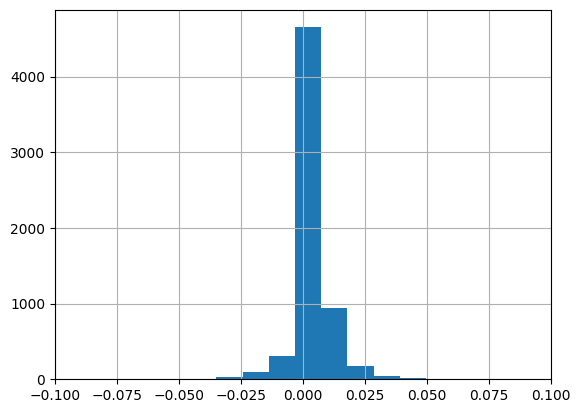

In [138]:
df_DAR_ion.coef.hist(bins=50)
plt.xlim(-0.1, 0.1)

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 71.79166666666667 mm


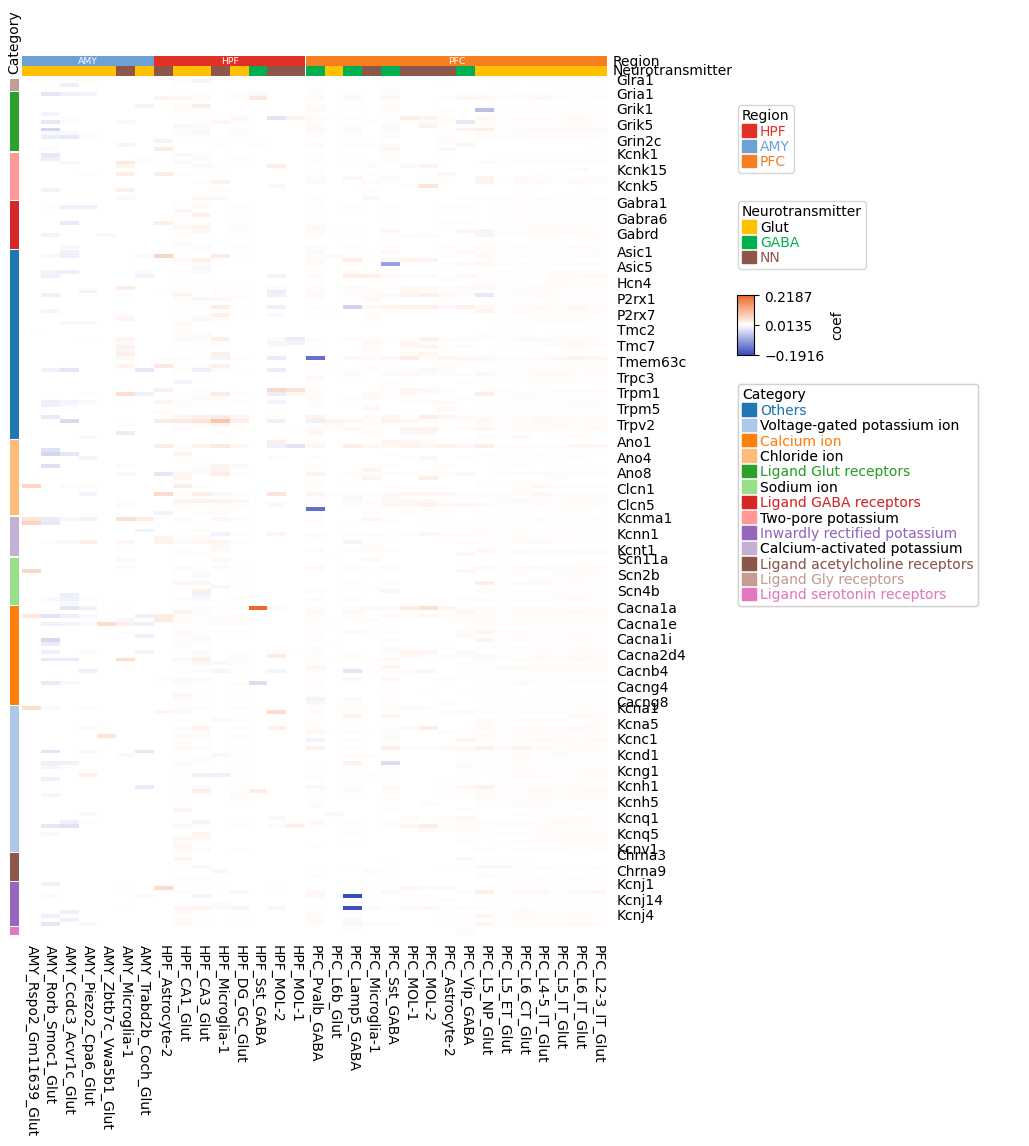

In [131]:
cm = draw_complex_heatmap(df_DAR_ion, value_col="coef")
